In [2]:
import pandas as pd
import pathlib as path 

df = pd.read_csv("../data/features_SOM_train_fulltest.csv")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDescribe:")
print(df.describe())

Shape: (94640, 6)

Columns:
Index(['HR', 'HRV_RMSSD', 'HRV_SDNN', 'SCR_Count', 'EDA_Tonic_log',
       'EDA_Phasic_log'],
      dtype='str')

Describe:
                 HR     HRV_RMSSD      HRV_SDNN     SCR_Count  EDA_Tonic_log  \
count  94640.000000  94640.000000  94640.000000  94640.000000   94640.000000   
mean      80.066498     69.745746     63.423947      0.936898       6.938545   
std       11.241744     45.706323     33.005219      1.238159       0.607125   
min       52.598237      7.850703     10.166059      0.000000      -5.000000   
25%       71.929622     35.730268     40.118531      0.000000       6.661611   
50%       79.242658     54.994327     55.899645      0.000000       6.756966   
75%       87.493492     92.216511     77.650820      2.000000       6.900997   
max      141.217339    200.000000    200.000000     13.000000      10.000000   

       EDA_Phasic_log  
count    94640.000000  
mean        -2.126226  
std          1.642081  
min         -5.000000  
25%    

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from som_model import GeneralCLASSOM

In [3]:
def topographic_error(som, data):

    error_count = 0

    for x in data:

        # avstånd till alla neuroner
        weights = som.get_weights()
        dists = np.linalg.norm(weights - x, axis=2)

        # hitta BMU och second BMU
        bmu_idx = np.unravel_index(np.argmin(dists), dists.shape)

        dists[bmu_idx] = np.inf
        second_bmu = np.unravel_index(np.argmin(dists), dists.shape)

        # kontrollera om de är grannar
        if max(abs(bmu_idx[0]-second_bmu[0]),
               abs(bmu_idx[1]-second_bmu[1])) > 1:
            error_count += 1

    return error_count / len(data)

In [4]:
data_path = Path("../data/features_SOM_train_fulltest.csv")

df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (94640, 6)


,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,EDA_Tonic_log,EDA_Phasic_log
0,78.301730,148.430157,123.485436,0,6.911910,1.344227
1,78.510768,146.875923,122.696557,0,6.926749,-0.330758
2,78.784907,143.014692,121.269201,0,6.941426,0.761282
3,79.601185,141.257924,120.203535,0,6.955931,0.469750
4,80.593733,139.251101,107.670513,0,6.970243,0.452715


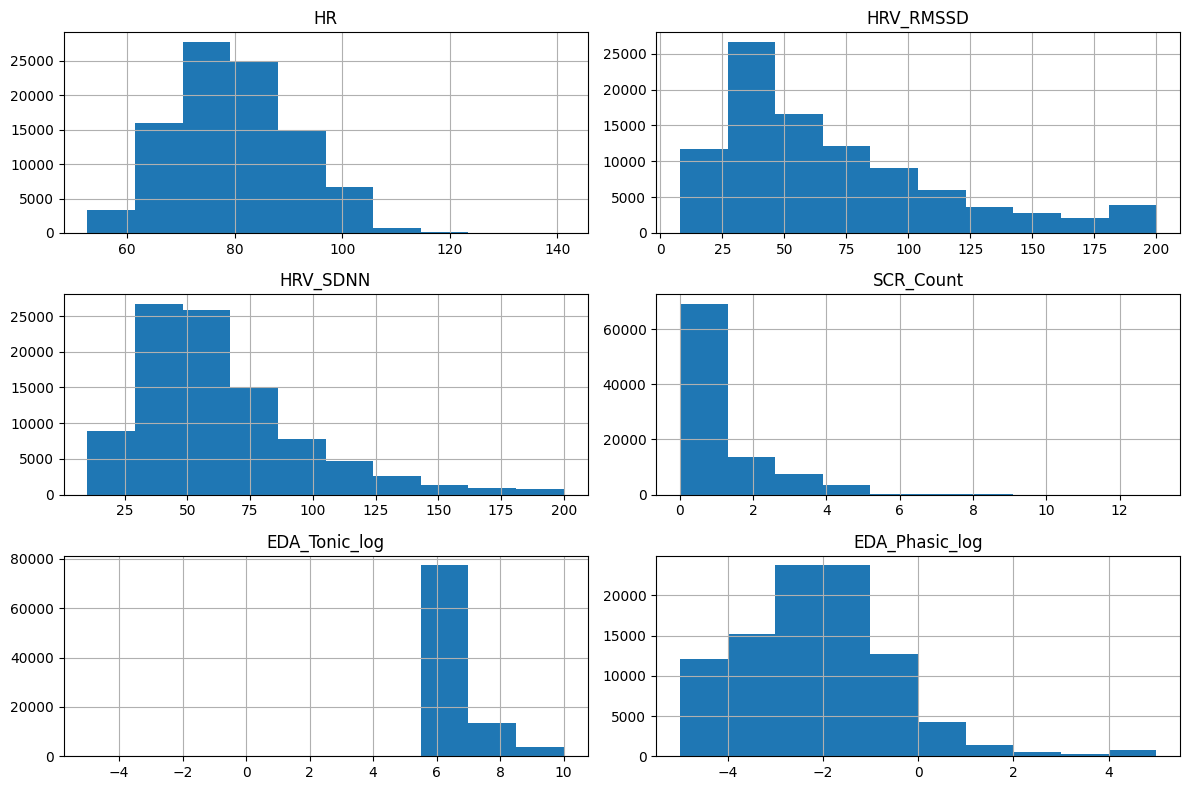

In [5]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [5]:
X = df.values

print(X.shape)

(94640, 6)


In [6]:
som = GeneralCLASSOM(

    x=45,
    y=45,
    input_len=6,

    sigma=12,
    learning_rate=0.3,

    random_seed=42
)

som.get_summary()

{'x': 45,
 'y': 45,
 'input_len': 6,
 'sigma': 12,
 'learning_rate': 0.3,
 'decay_function': 'asymptotic_decay',
 'neighborhood_function': 'gaussian',
 'topology': 'rectangular',
 'activation_distance': 'euclidean',
 'sigma_decay_function': 'asymptotic_decay',
 'random_seed': 42}

In [8]:
som.train(

    X,

    iterations=300000,
    mode="batch",

    use_pca=True,
    verbose=True
)

 [ 300000 / 300000 ] 100% - 0:00:00 left 
 quantization error: 2.0029284370522658
Training completed (300000 iterations)


In [9]:
scaled_train = som.scaler.transform(X)

qe = som.som.quantization_error(scaled_train)

te = topographic_error(
    som.som,
    scaled_train
)

print("Quantization Error:", qe)
print("Topographic Error:", te)

Quantization Error: 2.0029284370522658
Topographic Error: 0.035291631445477596


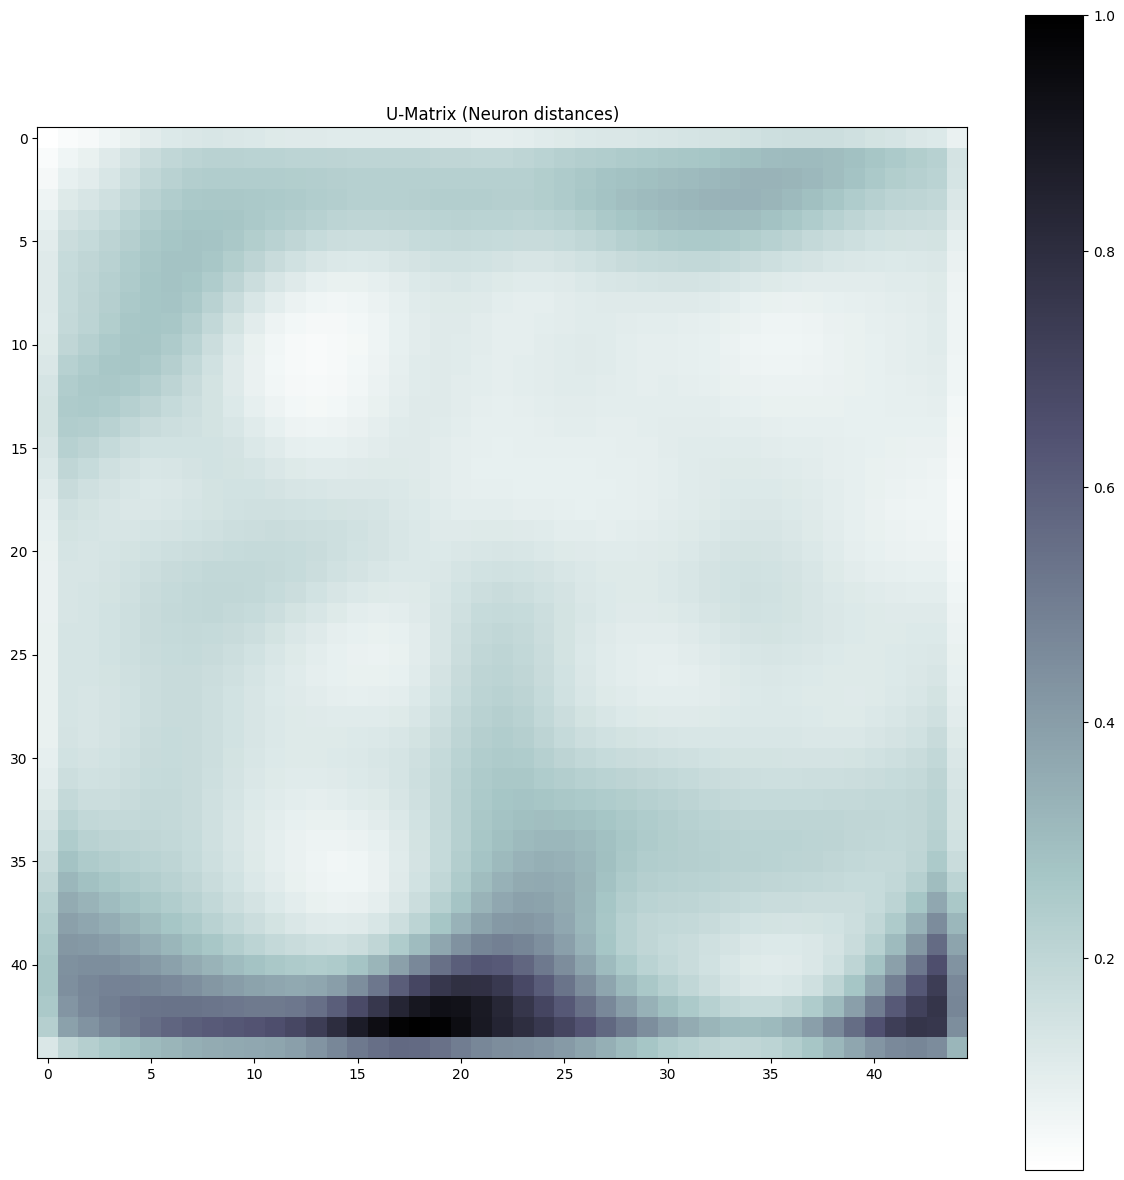

In [11]:
u_matrix = som.get_u_matrix()

plt.figure(figsize=(15,15))
plt.imshow(u_matrix, cmap="bone_r")
plt.colorbar()
plt.title("U-Matrix (Neuron distances)")
plt.show()

In [12]:
cluster_map = som.create_clusters(
    data=X,
    n_clusters=3,
    method="density"
)

In [13]:
u_matrix = som.get_u_matrix()

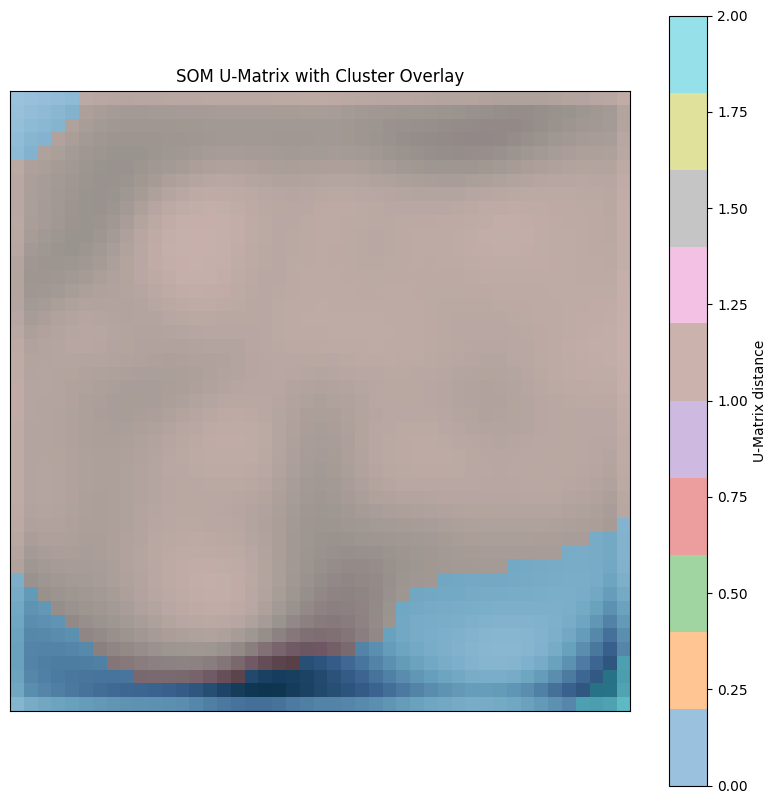

In [14]:
plt.figure(figsize=(10,10))

plt.imshow(u_matrix, cmap="bone_r")

plt.imshow(
    cluster_map,
    cmap="tab10",
    alpha=0.45
)

plt.colorbar(label="U-Matrix distance")

plt.title("SOM U-Matrix with Cluster Overlay")

plt.xticks([])
plt.yticks([])

plt.show()

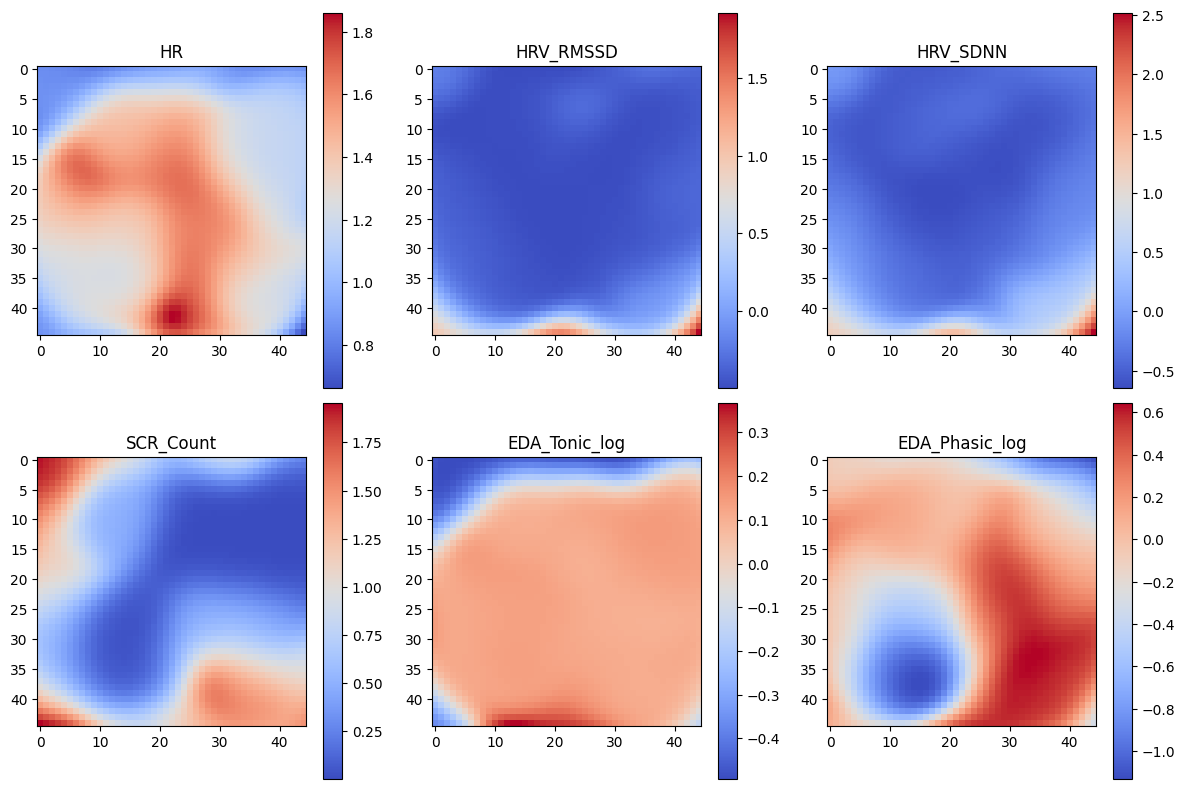

In [15]:
weights = som.som.get_weights()

features = df.columns

fig, axes = plt.subplots(2,3, figsize=(12,8))

for i, ax in enumerate(axes.flat):

    im = ax.imshow(weights[:,:,i], cmap="coolwarm")
    ax.set_title(features[i])

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

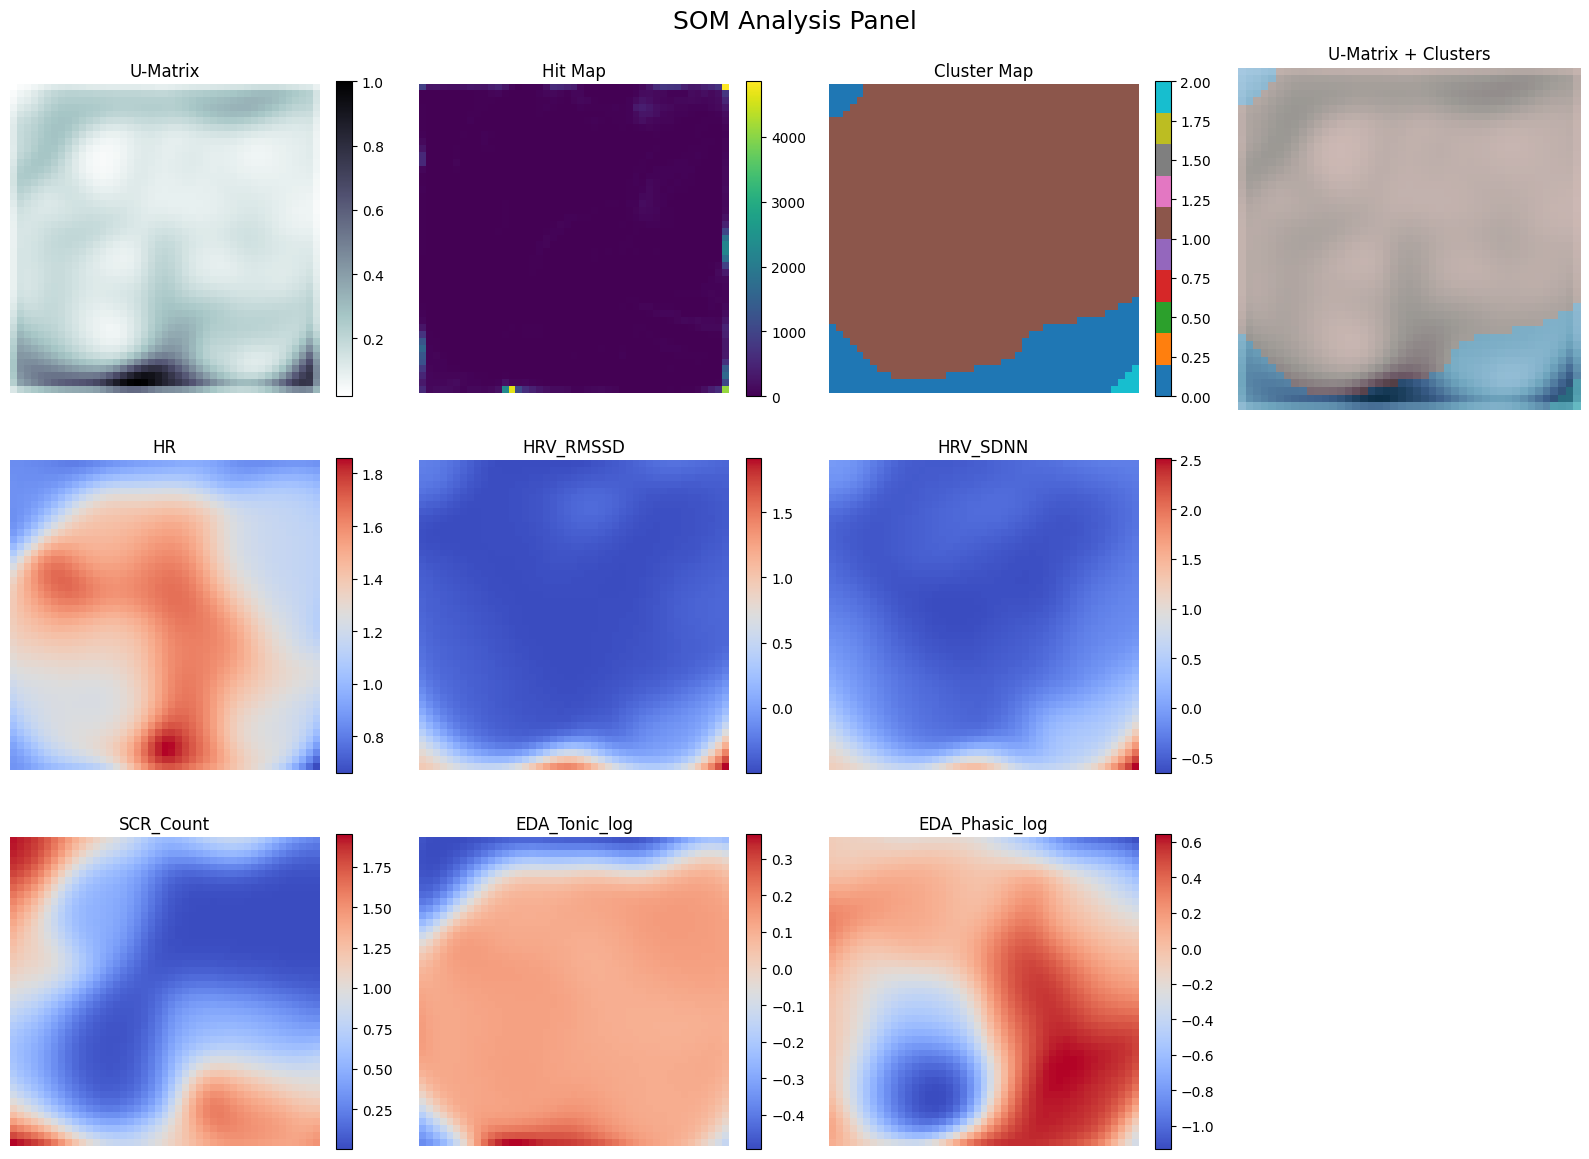

In [16]:
# ===== COMPLETE SOM VISUALIZATION PANEL =====

import matplotlib.pyplot as plt
import numpy as np

# ---- Prepare data ----
scaled_data = som.scaler.transform(X)

u_matrix = som.get_u_matrix()

hits = som.som.activation_response(scaled_data)

cluster_map = som.create_clusters(
    data=X,
    n_clusters=3,
    method="density"
)

weights = som.som.get_weights()

feature_names = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Count",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

# ---- Figure layout ----
fig = plt.figure(figsize=(16,12))

grid = fig.add_gridspec(3,4)

# ---- U-Matrix ----
ax1 = fig.add_subplot(grid[0,0])
im = ax1.imshow(u_matrix, cmap="bone_r")
ax1.set_title("U-Matrix")
ax1.axis("off")
plt.colorbar(im, ax=ax1, fraction=0.046)

# ---- Hit Map ----
ax2 = fig.add_subplot(grid[0,1])
im = ax2.imshow(hits, cmap="viridis")
ax2.set_title("Hit Map")
ax2.axis("off")
plt.colorbar(im, ax=ax2, fraction=0.046)

# ---- Cluster Map ----
ax3 = fig.add_subplot(grid[0,2])
im = ax3.imshow(cluster_map, cmap="tab10")
ax3.set_title("Cluster Map")
ax3.axis("off")
plt.colorbar(im, ax=ax3, fraction=0.046)

# ---- U-Matrix + Cluster Overlay ----
ax4 = fig.add_subplot(grid[0,3])
ax4.imshow(u_matrix, cmap="bone_r")
ax4.imshow(cluster_map, cmap="tab10", alpha=0.4)
ax4.set_title("U-Matrix + Clusters")
ax4.axis("off")

# ---- Feature Maps ----
for i in range(6):

    row = 1 + i // 3
    col = i % 3

    ax = fig.add_subplot(grid[row, col])

    im = ax.imshow(weights[:,:,i], cmap="coolwarm")
    ax.set_title(feature_names[i])
    ax.axis("off")

    plt.colorbar(im, ax=ax, fraction=0.046)

# ---- Layout ----
plt.suptitle("SOM Analysis Panel", fontsize=18)
plt.tight_layout()
plt.show()

In [17]:
df["cluster"] = som.predict_cluster(X)

cluster_profiles = df.groupby("cluster").mean()

cluster_profiles

,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,EDA_Tonic_log,EDA_Phasic_log
cluster,,,,,,
0,77.511603,86.059097,75.923792,1.403987,7.164586,-1.706167
1,81.371069,43.248399,43.915590,0.604688,6.851124,-2.272325
2,80.921846,169.431640,135.206561,1.322862,6.700818,-2.662676


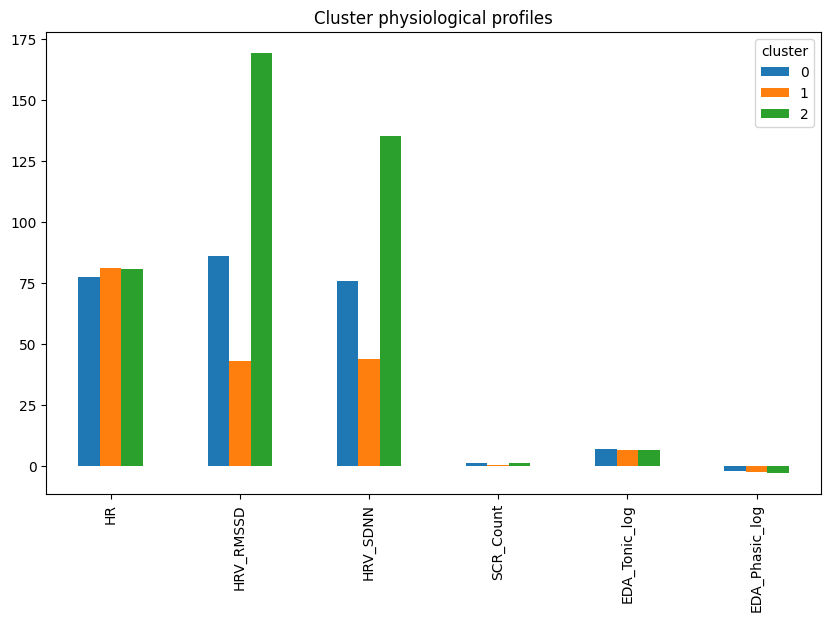

In [18]:

cluster_profiles.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Cluster physiological profiles")
plt.show()

In [19]:
df["cluster"].value_counts()

cluster
1    54352
0    30897
2     9391
Name: count, dtype: int64

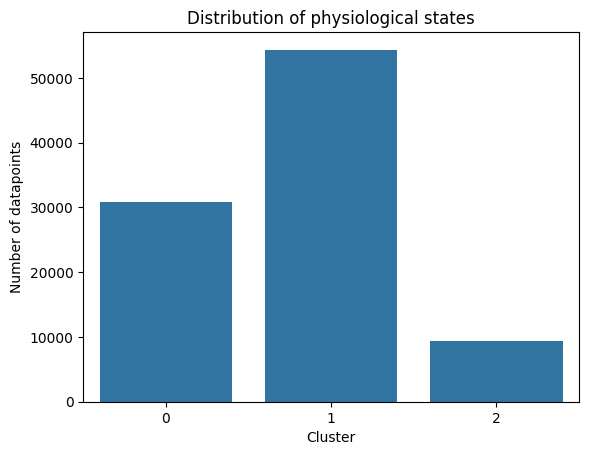

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="cluster", data=df)

plt.title("Distribution of physiological states")
plt.xlabel("Cluster")
plt.ylabel("Number of datapoints")

plt.show()

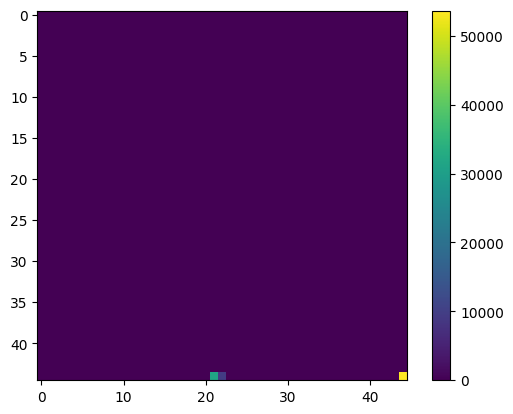

In [21]:
activation = som.som.activation_response(X)

plt.imshow(activation)
plt.colorbar()

In [22]:
# --------------------------------
# cluster → stress label
# --------------------------------

cluster_to_label = {
    2: 0,   # rest
    0: 1,   # baseline
    1: 2    # stress
}

cluster_to_state = {
    2: "rest",
    0: "baseline",
    1: "stress"
}

som.cluster_to_state = cluster_to_state
som.cluster_to_label = cluster_to_label

In [23]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "stress_som_model.pkl"

som.save_model(model_path)

print("Model saved to:", model_path)

Model saved to: ..\models\stress_som_model.pkl
